In [1]:
import numpy as np
import pybamm

model = pybamm.lithium_ion.DFN({
# model = pybamm.lithium_ion.SPM({

#     "SEI": "solvent-diffusion limited",
#     "SEI on cracks": "true",
# #     "lithium plating": "partially reversible",
#     "lithium plating": "irreversible",
#     "lithium plating porosity change": "true",
    
})

param = pybamm.ParameterValues("OKane2022")

solver = pybamm.CasadiSolver(
    mode="safe",
    atol=1e-6, #koko
    rtol=1e-6, #koko
)
pybamm.set_logging_level("INFO")

experiment_cc = pybamm.Experiment([
    (
        "Charge at 0.2C until 4.2 V",
        "Rest for 60 minutes",
        "Discharge at 0.2C until 3.2 V",
        "Rest for 60 minutes",
    )
] * 1)

sim_cc = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=experiment_cc,
    solver=solver,
)
solution_cc = sim_cc.solve()

2026-02-21 13:16:45.170 - [INFO] callbacks.on_experiment_start(164): Start running experiment
2026-02-21 13:16:45.171 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-21 13:16:45.210 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-21 13:16:45.212 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-21 13:16:45.251 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-21 13:16:45.252 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-21 13:16:45.292 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-21 13:16:45.296 - [INFO] discretisation.process_model(161): Start discretising Doyle-Fuller-Newman model
2026-02-21

In [2]:
freq_list = np.logspace(-1, 3, 100) #koko # 0.1 Hz ～ 1 kHz
Z_list = []

for freq in freq_list:
    
    model.set_initial_conditions_from(solution_cc)


    # =========================
    # AC 電流設定
    # =========================
    I0 = 0.01 #koko
    N_cycle = 100 #koko
    T_ac = N_cycle / freq

    t = pybamm.t
    ac_current = I0 * pybamm.sin(2 * np.pi * freq * t)



    param.update({
        "Current function [A]": ac_current
    })



    sim_ac = pybamm.Simulation(
        model,
        parameter_values=param,
        solver=solver,
    )

    solution_ac = sim_ac.solve([0, T_ac])


    # =========================
    # 電流・電圧取得
    # =========================
    I = solution_ac["Current [A]"].entries
    V = solution_ac["Terminal voltage [V]"].entries
    t = solution_ac["Time [s]"].entries

    I_ac = I - np.mean(I)
    V_ac = V - np.mean(V)


    
    T = 1 / freq
    mask = t > (t[-1] - 4*T) #koko

    I_use = I_ac[mask]
    V_use = V_ac[mask]
    t_use = t[mask]
    

    # =========================
    # FFT
    # =========================
    Iw = np.fft.fft(I_use)
    Vw = np.fft.fft(V_use)

    dt = t_use[1] - t_use[0]
    freqs = np.fft.fftfreq(len(t_use), d=dt)

    k = np.argmin(np.abs(freqs - freq))

    Z = -Vw[k] / Iw[k]
    Z_list.append(Z)

2026-02-21 13:16:46.947 - [INFO] parameter_substitutor.process_model(400): Start setting parameters for Doyle-Fuller-Newman model
2026-02-21 13:16:46.986 - [INFO] parameter_substitutor.process_model(483): Finish setting parameters for Doyle-Fuller-Newman model
2026-02-21 13:16:46.988 - [INFO] discretisation.process_model(161): Start discretising Doyle-Fuller-Newman model
2026-02-21 13:16:47.095 - [INFO] discretisation.process_model(282): Finish discretising Doyle-Fuller-Newman model
2026-02-21 13:16:47.097 - [INFO] base_solver.solve(798): Start solving Doyle-Fuller-Newman model with CasADi solver with 'safe' mode
2026-02-21 13:16:47.102 - [INFO] base_solver.set_up(169): Start solver set-up
2026-02-21 13:16:47.185 - [INFO] casadi_algebraic_solver.set_up_root_solver(89): Start building CasADi algebraic solver
2026-02-21 13:16:47.191 - [INFO] casadi_algebraic_solver.set_up_root_solver(152): Finish building CasADi algebraic solver
2026-02-21 13:16:47.192 - [INFO] base_solver.set_up(318): F

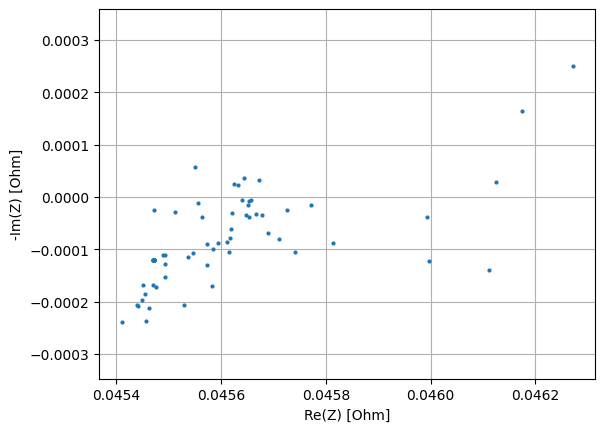

In [3]:
import matplotlib.pyplot as plt

Z_real = np.real(Z_list)
Z_imag = np.imag(Z_list)

plt.figure()
plt.plot(Z_real, -Z_imag, 'o', markersize=2) 
plt.xlabel("Re(Z) [Ohm]")
plt.ylabel("-Im(Z) [Ohm]")
plt.axis("equal")
plt.grid()
plt.show()